In [1]:
import sys

!{sys.executable} -m pip install xarray s3fs fsspec h5py h5netcdf netCDF4 pyproj pillow pandas numpy matplotlib tqdm

In [2]:
import os
import json
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import s3fs
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

In [3]:
DATA_DIR = Path("data")
FRAME_DIR = DATA_DIR / "frames"

DATA_DIR.mkdir(exist_ok=True)
FRAME_DIR.mkdir(exist_ok=True)

print("Data folder:", DATA_DIR.resolve())
print("Frames folder:", FRAME_DIR.resolve())

Data folder: /Users/jonathanchau/Desktop/dsc106/DSCProject03/data
Frames folder: /Users/jonathanchau/Desktop/dsc106/DSCProject03/data/frames


In [4]:
BUCKET = "noaa-goes16"
PRODUCT = "ABI-L2-MCMIPC"

START_TIME = dt.datetime(2020, 8, 26, 18)  # Aug 26, 2020 18:00 UTC
END_TIME = dt.datetime(2020, 8, 27, 6)     # Aug 27, 2020 06:00 UTC

fs = s3fs.S3FileSystem(anon=True)

In [5]:
def goes_s3_hour_path(bucket, product, timestamp):
    year = timestamp.year
    day_of_year = timestamp.timetuple().tm_yday
    hour = timestamp.hour

    return f"{bucket}/{product}/{year}/{day_of_year:03d}/{hour:02d}/*.nc"


def list_goes_files(bucket, product, start_time, end_time):
    files = []
    current = start_time.replace(minute=0, second=0, microsecond=0)

    while current <= end_time:
        pattern = goes_s3_hour_path(bucket, product, current)
        hour_files = fs.glob(pattern)
        files.extend(hour_files)
        current += dt.timedelta(hours=1)

    return sorted(files)


files = list_goes_files(BUCKET, PRODUCT, START_TIME, END_TIME)

print("Number of files found:", len(files))
print("First 3 files:")
for f in files[:3]:
    print(f)

Number of files found: 156
First 3 files:
noaa-goes16/ABI-L2-MCMIPC/2020/239/18/OR_ABI-L2-MCMIPC-M6_G16_s20202391801173_e20202391803552_c20202391804102.nc
noaa-goes16/ABI-L2-MCMIPC/2020/239/18/OR_ABI-L2-MCMIPC-M6_G16_s20202391806173_e20202391808552_c20202391809094.nc
noaa-goes16/ABI-L2-MCMIPC/2020/239/18/OR_ABI-L2-MCMIPC-M6_G16_s20202391811173_e20202391813558_c20202391814100.nc


In [6]:
files_sampled = files[::6]  # every 6th file

print("Number of files sampled:", len(files_sampled))
for f in files_sampled[:5]:
    print(f)

Number of files sampled: 26
noaa-goes16/ABI-L2-MCMIPC/2020/239/18/OR_ABI-L2-MCMIPC-M6_G16_s20202391801173_e20202391803552_c20202391804102.nc
noaa-goes16/ABI-L2-MCMIPC/2020/239/18/OR_ABI-L2-MCMIPC-M6_G16_s20202391831173_e20202391833557_c20202391834107.nc
noaa-goes16/ABI-L2-MCMIPC/2020/239/19/OR_ABI-L2-MCMIPC-M6_G16_s20202391901173_e20202391903546_c20202391904105.nc
noaa-goes16/ABI-L2-MCMIPC/2020/239/19/OR_ABI-L2-MCMIPC-M6_G16_s20202391931173_e20202391933557_c20202391934106.nc
noaa-goes16/ABI-L2-MCMIPC/2020/239/20/OR_ABI-L2-MCMIPC-M6_G16_s20202392001173_e20202392003557_c20202392004100.nc


In [10]:
# Pick one GOES file
sample_file = files_sampled[0]

print("Remote file:")
print(sample_file)

# Create local folder for raw GOES files
RAW_DIR = Path("data/raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)

# Local filename
local_file = RAW_DIR / Path(sample_file).name

print("Downloading to:")
print(local_file)

# Download only if it doesn't already exist
if not local_file.exists():
    fs.get(sample_file, str(local_file))
    print("Download complete.")
else:
    print("File already downloaded.")

Remote file:
noaa-goes16/ABI-L2-MCMIPC/2020/239/18/OR_ABI-L2-MCMIPC-M6_G16_s20202391801173_e20202391803552_c20202391804102.nc
data/raw/OR_ABI-L2-MCMIPC-M6_G16_s20202391801173_e20202391803552_c20202391804102.nc
Download complete.


In [11]:
ds_one = xr.open_dataset(local_file)

print("Opened local GOES file successfully")
print(ds_one.dims)
print(list(ds_one.data_vars)[:20])

Opened local GOES file successfully
FrozenMappingWarningOnValuesAccess({'y': 1500, 'x': 2500, 'number_of_time_bounds': 2, 'number_of_image_bounds': 2, 'band': 1})
['CMI_C01', 'DQF_C01', 'CMI_C02', 'DQF_C02', 'CMI_C03', 'DQF_C03', 'CMI_C04', 'DQF_C04', 'CMI_C05', 'DQF_C05', 'CMI_C06', 'DQF_C06', 'CMI_C07', 'DQF_C07', 'CMI_C08', 'DQF_C08', 'CMI_C09', 'DQF_C09', 'CMI_C10', 'DQF_C10']


In [12]:
print("CMI_C13 exists:", "CMI_C13" in ds_one.data_vars)
print(ds_one["CMI_C13"].shape)
print(ds_one["CMI_C13"].dtype)

CMI_C13 exists: True
(1500, 2500)
float32


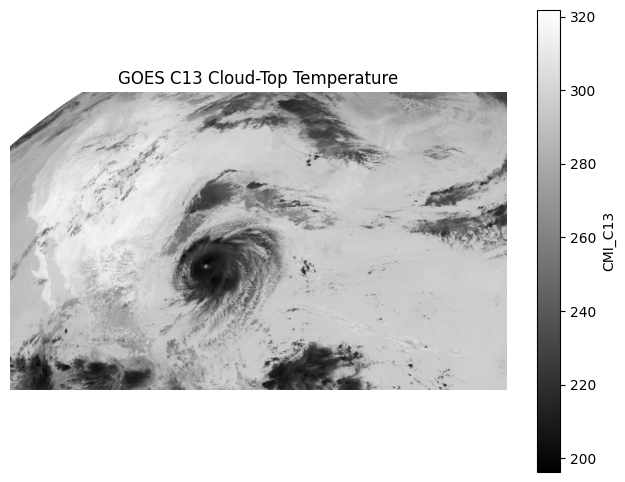

In [13]:
c13 = ds_one["CMI_C13"].values

plt.figure(figsize=(8, 6))
plt.imshow(c13, cmap="gray")
plt.colorbar(label="CMI_C13")
plt.title("GOES C13 Cloud-Top Temperature")
plt.axis("off")
plt.show()

In [14]:
print(c13.shape)

(1500, 2500)


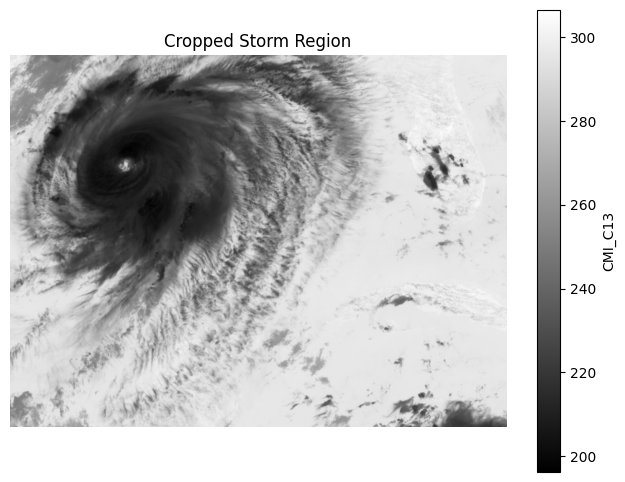

In [15]:
Y_START, Y_END = 700, 1300
X_START, X_END = 800, 1600

c13_crop = c13[Y_START:Y_END, X_START:X_END]

plt.figure(figsize=(8, 6))
plt.imshow(c13_crop, cmap="gray")
plt.colorbar(label="CMI_C13")
plt.title("Cropped Storm Region")
plt.axis("off")
plt.show()

In [16]:
from PIL import Image
import numpy as np

def normalize_to_uint8(arr, vmin=190, vmax=300, invert=True):
    arr = np.array(arr, dtype=float)
    arr = np.clip(arr, vmin, vmax)

    norm = (arr - vmin) / (vmax - vmin)

    if invert:
        norm = 1 - norm

    return (norm * 255).astype(np.uint8)

In [17]:
img_array = normalize_to_uint8(c13_crop, vmin=190, vmax=300, invert=True)
img = Image.fromarray(img_array)

FRAME_DIR.mkdir(parents=True, exist_ok=True)

img.save(FRAME_DIR / "c13_cloud_top_temp_test.png")

print("Saved test frame.")

Saved test frame.


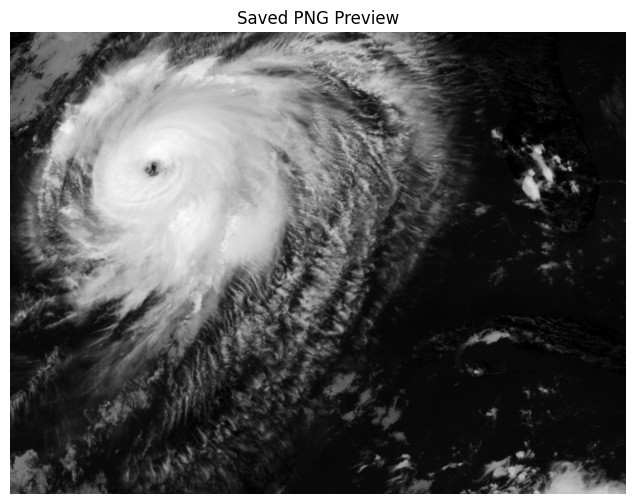

In [18]:
test_img = Image.open(FRAME_DIR / "c13_cloud_top_temp_test.png")

plt.figure(figsize=(8, 6))
plt.imshow(test_img, cmap="gray")
plt.title("Saved PNG Preview")
plt.axis("off")
plt.show()

In [19]:
frame_records = []
metrics_records = []

RAW_DIR = Path("data/raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)

for i, remote_file in enumerate(tqdm(files_sampled[:20])):  # start with 20 frames
    local_file = RAW_DIR / Path(remote_file).name

    # Download locally if needed
    if not local_file.exists():
        fs.get(remote_file, str(local_file))

    # Open local GOES file
    ds = xr.open_dataset(local_file)

    # Extract timestamp
    time_value = pd.to_datetime(ds["t"].values).isoformat()

    # Extract C13
    c13 = ds["CMI_C13"].values

    # Crop storm region
    c13_crop = c13[Y_START:Y_END, X_START:X_END]

    # Save PNG
    img_array = normalize_to_uint8(c13_crop, vmin=190, vmax=300, invert=True)
    img = Image.fromarray(img_array)

    filename = f"c13_cloud_top_temp_{i:03d}.png"
    filepath = FRAME_DIR / filename
    img.save(filepath)

    # Compute simple storm metrics
    valid = c13_crop[np.isfinite(c13_crop)]

    min_temp = float(np.nanmin(valid))
    mean_temp = float(np.nanmean(valid))
    cold_cloud_fraction = float(np.mean(valid < 220))
    intensity_proxy = cold_cloud_fraction * (260 - min_temp)

    frame_records.append({
        "frame": i,
        "time": time_value,
        "variable": "CMI_C13",
        "label": "Cloud-top temperature",
        "file": f"data/frames/{filename}"
    })

    metrics_records.append({
        "frame": i,
        "time": time_value,
        "min_cloud_top_temp_k": min_temp,
        "mean_cloud_top_temp_k": mean_temp,
        "cold_cloud_fraction": cold_cloud_fraction,
        "intensity_proxy": intensity_proxy
    })

print("Done exporting frames.")

100%|██████████| 20/20 [04:11<00:00, 12.57s/it]

Done exporting frames.


In [22]:
import json
from pathlib import Path

DATA_DIR = Path("data")
FRAME_DIR = DATA_DIR / "frames"

project_data = {
    "title": "How Do Storms Develop and Intensify?",
    "question": "How do storms develop and intensify based on underlying temperature, energy, and atmospheric structure?",
    "storm": "Hurricane Laura",
    "satellite": "GOES-16",
    "product": "ABI-L2-MCMIPC",
    "description": "This project uses GOES-16 C13 infrared imagery to explore how cloud-top temperature patterns changed as Hurricane Laura developed over time. Brighter regions in the exported frames represent colder cloud tops, which often indicate taller and stronger storm clouds.",
    "variables": {
        "CMI_C13": {
            "name": "Cloud-top temperature",
            "description": "GOES ABI Band 13 infrared brightness temperature. Colder cloud tops can indicate taller storm clouds and stronger convection.",
            "unit": "Kelvin",
            "visual_encoding": "Brighter pixels represent colder cloud tops."
        }
    },
    "frames": frame_records,
    "metrics": metrics_records,
    "notes": {
        "data_transformation": "The original GOES NetCDF files were downloaded, cropped to focus on the storm region, normalized, and exported as PNG frames for use in a browser-based D3 visualization.",
        "intensity_proxy": "The intensity proxy combines cold cloud fraction and minimum cloud-top temperature. It is not a direct measurement of hurricane intensity, but it helps summarize changes in storm structure over time."
    }
}

with open(DATA_DIR / "project_data.json", "w") as f:
    json.dump(project_data, f, indent=2)

print("Saved project_data.json")
print("Number of frames:", len(project_data["frames"]))
print("Number of metric rows:", len(project_data["metrics"]))

Saved project_data.json
Number of frames: 20
Number of metric rows: 20


In [23]:
with open("data/project_data.json", "r") as f:
    data = json.load(f)

print(data.keys())
print(data["frames"][0])
print(data["metrics"][0])

dict_keys(['title', 'question', 'storm', 'satellite', 'product', 'description', 'variables', 'frames', 'metrics', 'notes'])
{'frame': 0, 'time': '2020-08-26T18:02:36.279200', 'variable': 'CMI_C13', 'label': 'Cloud-top temperature', 'file': 'data/frames/c13_cloud_top_temp_000.png'}
{'frame': 0, 'time': '2020-08-26T18:02:36.279200', 'min_cloud_top_temp_k': 196.24151611328125, 'mean_cloud_top_temp_k': 270.41912841796875, 'cold_cloud_fraction': 0.08868333333333334, 'intensity_proxy': 5.654314879353842}
